Using device: cuda


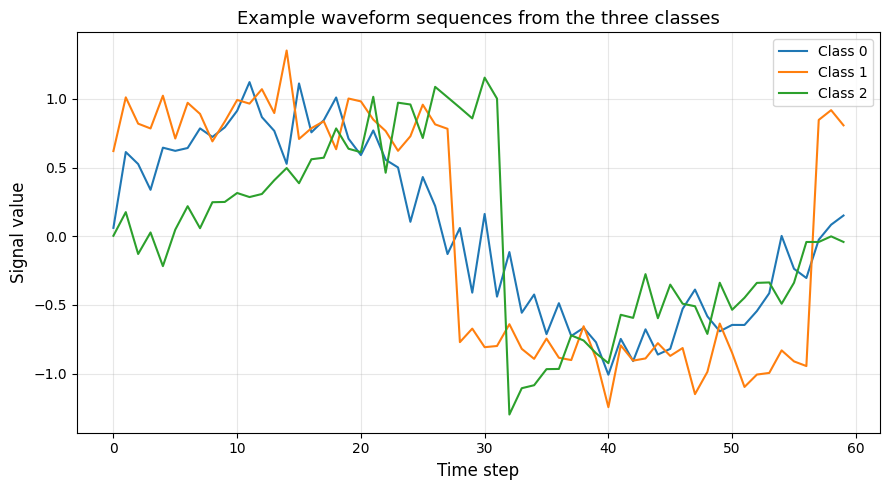


Training GRU
Epoch 01/10 | train_acc=0.3887 | val_acc=0.4700 | train_loss=1.0835 | val_loss=1.0283 | time=0.75s
Epoch 02/10 | train_acc=0.5413 | val_acc=0.6933 | train_loss=0.8892 | val_loss=0.5965 | time=0.08s
Epoch 03/10 | train_acc=0.7847 | val_acc=0.8733 | train_loss=0.5129 | val_loss=0.3942 | time=0.07s
Epoch 04/10 | train_acc=0.8760 | val_acc=0.8900 | train_loss=0.3228 | val_loss=0.2782 | time=0.08s
Epoch 05/10 | train_acc=0.9073 | val_acc=0.9133 | train_loss=0.2322 | val_loss=0.1901 | time=0.07s
Epoch 06/10 | train_acc=0.9587 | val_acc=0.9633 | train_loss=0.1394 | val_loss=0.1074 | time=0.07s
Epoch 07/10 | train_acc=0.9847 | val_acc=0.9200 | train_loss=0.0779 | val_loss=0.1666 | time=0.07s
Epoch 08/10 | train_acc=0.9813 | val_acc=0.9733 | train_loss=0.0653 | val_loss=0.0643 | time=0.07s
Epoch 09/10 | train_acc=0.9920 | val_acc=0.9933 | train_loss=0.0391 | val_loss=0.0298 | time=0.07s
Epoch 10/10 | train_acc=0.9987 | val_acc=1.0000 | train_loss=0.0194 | val_loss=0.0215 | time=0.

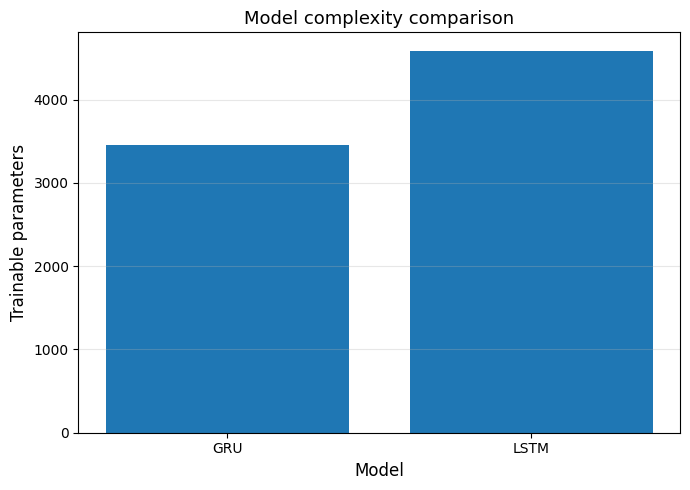

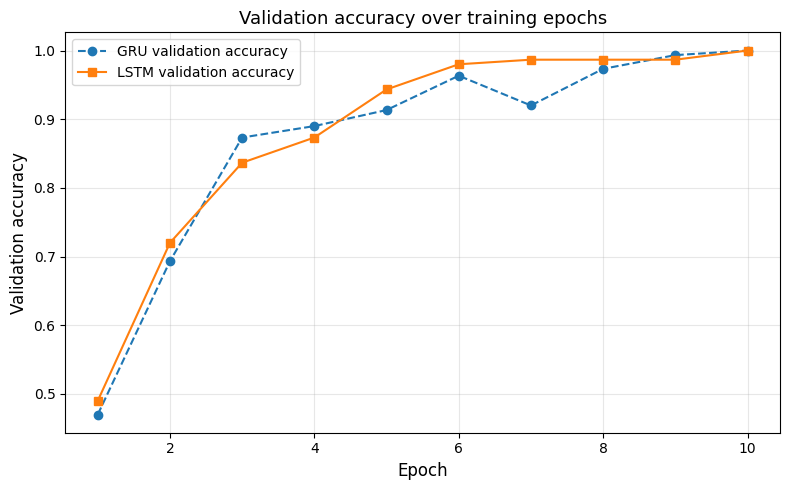

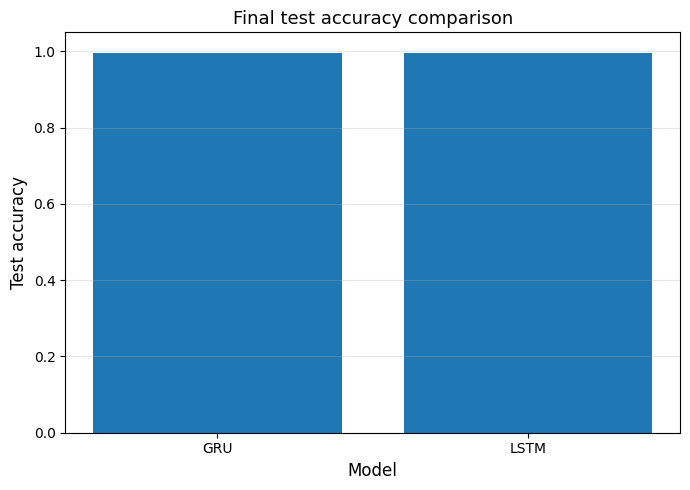

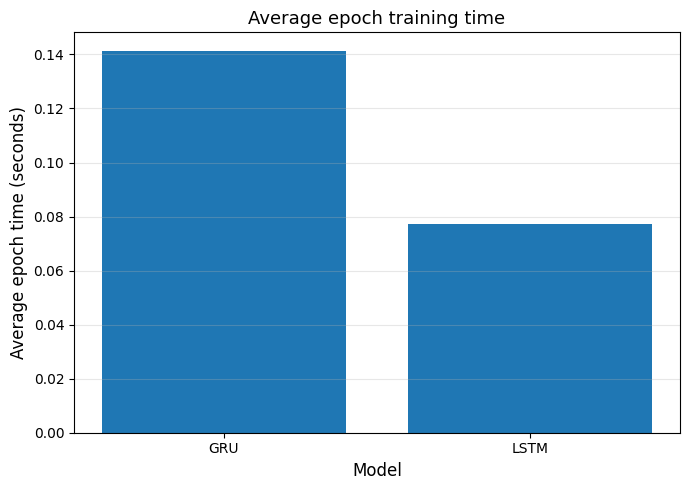

In [1]:
# Single-cell tutorial experiment: GRU vs LSTM on waveform sequence classification

import random
import time
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --------------------------------------------------
# 1. Reproducibility and device
# --------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# --------------------------------------------------
# 2. Synthetic waveform dataset
# Classes:
# 0 = noisy sine wave
# 1 = noisy square wave
# 2 = noisy sawtooth-like wave
# --------------------------------------------------
class WaveformSequenceDataset(Dataset):
    def __init__(self, num_samples, seq_len=60, noise_std=0.15):
        self.num_samples = num_samples
        self.seq_len = seq_len
        self.noise_std = noise_std

        X = []
        y = []

        t = np.linspace(0, 2 * np.pi, seq_len)

        for _ in range(num_samples):
            cls = np.random.randint(0, 3)

            amplitude = np.random.uniform(0.8, 1.2)
            phase = np.random.uniform(-0.3, 0.3)

            if cls == 0:
                signal = amplitude * np.sin(t + phase)

            elif cls == 1:
                signal = amplitude * np.sign(np.sin(t + phase))

            else:
                # sawtooth-like waveform scaled to roughly [-1, 1]
                raw = (t + phase) / (2 * np.pi)
                signal = amplitude * (2 * (raw - np.floor(raw + 0.5)))

            noise = np.random.normal(0, noise_std, size=seq_len)
            sequence = signal + noise

            X.append(sequence.reshape(seq_len, 1).astype(np.float32))
            y.append(cls)

        self.X = np.array(X, dtype=np.float32)
        self.y = np.array(y, dtype=np.int64)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

# --------------------------------------------------
# 3. Example task visualization
# --------------------------------------------------
example_dataset = WaveformSequenceDataset(num_samples=9, seq_len=60, noise_std=0.15)

plt.figure(figsize=(9, 5))
for cls in range(3):
    idx = np.where(example_dataset.y == cls)[0][0]
    seq = example_dataset.X[idx].squeeze(-1)
    plt.plot(seq, label=f"Class {cls}")
plt.title("Example waveform sequences from the three classes", fontsize=13)
plt.xlabel("Time step", fontsize=12)
plt.ylabel("Signal value", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 4. Model definitions
# --------------------------------------------------
class GRUClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, num_classes=3):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        final_hidden = out[:, -1, :]
        return self.fc(final_hidden)

class LSTMClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        final_hidden = out[:, -1, :]
        return self.fc(final_hidden)

# --------------------------------------------------
# 5. Utility functions
# --------------------------------------------------
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)
            loss = criterion(logits, y)

            total_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == y).sum().item()
            total_samples += X.size(0)

    return total_loss / total_samples, total_correct / total_samples

def train_model(model, train_loader, val_loader, epochs=10, lr=0.002):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }
    epoch_times = []

    for epoch in range(epochs):
        start = time.time()
        model.train()

        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == y).sum().item()
            train_total += X.size(0)

        train_loss = train_loss_sum / train_total
        train_acc = train_correct / train_total
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        epoch_time = time.time() - start
        epoch_times.append(epoch_time)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"time={epoch_time:.2f}s"
        )

    return history, epoch_times

# --------------------------------------------------
# 6. Data loaders
# --------------------------------------------------
seq_len = 60
train_size = 1500
val_size = 300
test_size = 300
batch_size = 64
epochs = 10
hidden_size = 32
learning_rate = 0.002
noise_std = 0.15

train_ds = WaveformSequenceDataset(train_size, seq_len=seq_len, noise_std=noise_std)
val_ds = WaveformSequenceDataset(val_size, seq_len=seq_len, noise_std=noise_std)
test_ds = WaveformSequenceDataset(test_size, seq_len=seq_len, noise_std=noise_std)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(test_ds, batch_size=batch_size)

# --------------------------------------------------
# 7. Train GRU
# --------------------------------------------------
print("\nTraining GRU")
gru_model = GRUClassifier(hidden_size=hidden_size).to(DEVICE)
gru_params = count_parameters(gru_model)
gru_history, gru_epoch_times = train_model(
    gru_model, train_loader, val_loader, epochs=epochs, lr=learning_rate
)
criterion = nn.CrossEntropyLoss()
gru_test_loss, gru_test_acc = evaluate(gru_model, test_loader, criterion)

# --------------------------------------------------
# 8. Train LSTM
# --------------------------------------------------
print("\nTraining LSTM")
lstm_model = LSTMClassifier(hidden_size=hidden_size).to(DEVICE)
lstm_params = count_parameters(lstm_model)
lstm_history, lstm_epoch_times = train_model(
    lstm_model, train_loader, val_loader, epochs=epochs, lr=learning_rate
)
lstm_test_loss, lstm_test_acc = evaluate(lstm_model, test_loader, criterion)

# --------------------------------------------------
# 9. Printed summary table
# --------------------------------------------------
print("\n" + "=" * 72)
print("SUMMARY RESULTS")
print("=" * 72)
print(f"{'Model':<10}{'Parameters':<15}{'Avg Epoch Time(s)':<20}{'Best Val Acc':<15}{'Test Acc':<10}")
print("-" * 72)
print(f"{'GRU':<10}{gru_params:<15}{np.mean(gru_epoch_times):<20.4f}{max(gru_history['val_acc']):<15.4f}{gru_test_acc:<10.4f}")
print(f"{'LSTM':<10}{lstm_params:<15}{np.mean(lstm_epoch_times):<20.4f}{max(lstm_history['val_acc']):<15.4f}{lstm_test_acc:<10.4f}")

# --------------------------------------------------
# 10. Plot 1: Parameter count comparison
# --------------------------------------------------
plt.figure(figsize=(7, 5))
plt.bar(["GRU", "LSTM"], [gru_params, lstm_params])
plt.title("Model complexity comparison", fontsize=13)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Trainable parameters", fontsize=12)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 11. Plot 2: Validation accuracy over epochs
# --------------------------------------------------
epoch_axis = range(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epoch_axis, gru_history["val_acc"], marker="o", linestyle="--", label="GRU validation accuracy")
plt.plot(epoch_axis, lstm_history["val_acc"], marker="s", linestyle="-", label="LSTM validation accuracy")
plt.title("Validation accuracy over training epochs", fontsize=13)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation accuracy", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 12. Plot 3: Final test accuracy comparison
# --------------------------------------------------
plt.figure(figsize=(7, 5))
plt.bar(["GRU", "LSTM"], [gru_test_acc, lstm_test_acc])
plt.title("Final test accuracy comparison", fontsize=13)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Test accuracy", fontsize=12)
plt.ylim(0, 1.05)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 13. Plot 4: Average training time comparison
# --------------------------------------------------
plt.figure(figsize=(7, 5))
plt.bar(["GRU", "LSTM"], [np.mean(gru_epoch_times), np.mean(lstm_epoch_times)])
plt.title("Average epoch training time", fontsize=13)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Average epoch time (seconds)", fontsize=12)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()